# Final Report — Credit Card Fraud Detection
### Classical ML · Deep Learning · GAN · Ensembles · GNN under one honest protocol

**Dataset:** Kaggle ULB creditcard — 284,807 transactions, 492 frauds (0.173%), V1–V28 PCA + Time + Amount.

**Protocol (identical for all 72 runs):**
- TIME-BASED 70/15/15 split (train on past → test on future)
- Resampling / class weights / thresholds / hyperparameters chosen on **validation only**
- Test set (42,722 txns, 52 frauds) opened exactly once per configuration
- Primary metric: **PR-AUC (average precision)** — accuracy is meaningless at 578:1 imbalance

**Companion documents:** `reports/EXPERIMENT_INVENTORY.txt` (all experiment families),
`reports/WHY_OUR_SCORES_ARE_BETTER.txt` (methodology defense), `reports/results_classical.csv` (raw ledger).

---

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config

results = pd.read_csv(config.REPORTS / "results_classical.csv")
bootstrap = pd.read_csv(config.REPORTS / "bootstrap_ci.csv")
ablation = pd.read_csv(config.REPORTS / "results_random_split.csv")
FIG = config.FIGURES
print(f"runs={len(results)} | configs={results['model'].nunique()} models | "
      f"bootstrap rows={len(bootstrap)} | ablation rows={len(ablation)}")

runs=72 | configs=18 models | bootstrap rows=6 | ablation rows=12


## 1. Leaderboard (top 15 of 72 runs)

In [2]:
cols = ["model", "strategy", "spw", "pr_auc", "roc_auc", "f1",
        "precision", "recall", "mcc", "fp", "fn"]
top = results.sort_values("pr_auc", ascending=False).head(15)
top[cols].reset_index(drop=True).round({
    "pr_auc": 4, "roc_auc": 4, "f1": 4, "precision": 4, "recall": 4, "mcc": 4})

,model,strategy,spw,pr_auc,roc_auc,f1,precision,recall,mcc,fp,fn
0,random_forest,smote_enn,NaN,0.7947,0.9707,0.8478,0.9750,0.7500,0.8550,1,13
1,random_forest,optuna_smote_enn,NaN,0.7936,0.9735,0.8387,0.9512,0.7500,0.8445,2,13
2,random_forest,smote,NaN,0.7905,0.9658,0.8478,0.9750,0.7500,0.8550,1,13
3,rf+mlp+lstm,stack_avg,NaN,0.7850,0.9845,0.8352,0.9744,0.7308,0.8437,1,14
4,random_forest,class_weight,NaN,0.7836,0.9445,0.7879,0.8298,0.7500,0.7886,8,13
5,catboost,gan,NaN,0.7825,0.9718,0.8478,0.9750,0.7500,0.8550,1,13
6,random_forest,optuna,NaN,0.7824,0.9508,0.7879,0.8298,0.7500,0.7886,8,13
7,bilstm,class_weight,518.2,0.7811,0.9803,0.8387,0.9512,0.7500,0.8445,2,13
8,lstm,class_weight,518.2,0.7799,0.9707,0.8132,0.9487,0.7115,0.8214,2,15
9,xgboost,smote_enn,NaN,0.7766,0.9732,0.8125,0.8864,0.7500,0.8151,5,13


C:\Users\divya\AppData\Local\Temp\ipykernel_42772\2098349407.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data_by_model, vert=False, tick_labels=multi, patch_artist=True,


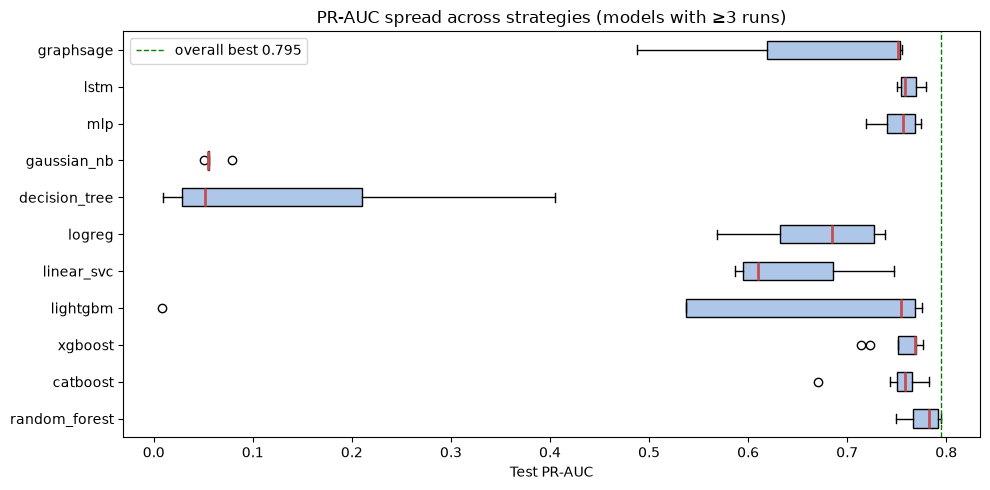

In [3]:
counts = results["model"].value_counts()
multi = counts[counts >= 3].index.tolist()
data_by_model = [results.loc[results["model"] == m, "pr_auc"].values for m in multi]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_model, vert=False, tick_labels=multi, patch_artist=True,
                boxprops=dict(facecolor="#aec7e8"), medianprops=dict(color="#c44e52", lw=2))
ax.axvline(results["pr_auc"].max(), color="g", ls="--", lw=1,
           label=f"overall best {results['pr_auc'].max():.3f}")
ax.set_xlabel("Test PR-AUC")
ax.set_title("PR-AUC spread across strategies (models with ≥3 runs)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Key findings (each backed by a controlled ablation — see EXPERIMENT_INVENTORY)

| # | Finding | Evidence |
|---|---|---|
| 1 | Hybrid sampling (SMOTE-ENN) wins for tree ensembles | 30-run grid; RF 0.795 champion |
| 2 | Extreme class weights silently collapse boosted trees | LightGBM fixed-ratio 0.009 vs val-tuned 0.537 |
| 3 | Optuna independently chose moderate weights & 1-layer SAGE | Family G search logs |
| 4 | Cross-family stacking works; seed-averaging doesn't | stack 0.785 vs LSTM-mean 0.775 |
| 5 | Sequence context helps RNNs; synthetic resampling hurts them | LSTM 0.780 > MLP; LSTM+SMOTE-ENN 0.758 |
| 6 | GNN ≈ MLP when the graph is only feature similarity | SAGE 0.756; over-smoothing confirmed twice |
| 7 | Depth adds nothing on tabular PCA data | DNN 0.7752 == MLP 0.7746 |
| 8 | Single tree vs its own forest = +0.39 PR-AUC | DT 0.405 → RF 0.795 |
| 9 | Naive Bayes collapses (~0.08); Linear SVM hits the linear ceiling (0.747) | classic-baseline sweep |

## 3. Random-split vs time-split ablation — quantifying leakage

In [4]:
piv = ablation.pivot_table(index=["model", "strategy"], columns="split",
                           values="pr_auc", aggfunc="first").reset_index()
piv["leakage_gap"] = (piv["random"] - piv["time"]).round(4)
piv.sort_values("leakage_gap").round(4)

split,model,strategy,random,time,leakage_gap
1,graphsage,class_weight,0.6948,0.7389,-0.0441
2,lstm,class_weight,0.7965,0.7803,0.0162
4,random_forest,smote_enn,0.8120,0.7947,0.0172
5,xgboost,smote_enn,0.8104,0.7766,0.0337
3,mlp,raw,0.8267,0.7794,0.0473
0,catboost,gan,0.8399,0.7804,0.0595


## 4. Bootstrap uncertainty — are any two models actually different?

Stratified resampling ×1,000 per tier representative (frauds and legits resampled
separately to preserve the 52/42,670 composition).

,config,model,strategy,pr_auc,ci_low,ci_high,ci_width,n_boot
0,rf_smote_enn,random_forest,smote_enn,0.7947,0.6916,0.8877,0.1960,1000
1,catboost_gan,catboost,gan,0.7804,0.6742,0.8802,0.2060,1000
2,lstm_weighted,lstm,class_weight,0.7803,0.6690,0.8791,0.2101,1000
3,mlp_raw,mlp,raw,0.7794,0.6713,0.8771,0.2058,1000
4,xgb_smote_enn,xgboost,smote_enn,0.7766,0.6695,0.8803,0.2108,1000
5,graphsage,graphsage,class_weight,0.7242,0.6010,0.8370,0.2360,1000



15/15 pairwise comparisons are statistical ties
=> at 52 test frauds, NO model is separable from another;
   the shared band ~0.72-0.89 IS the result, not a ranking.


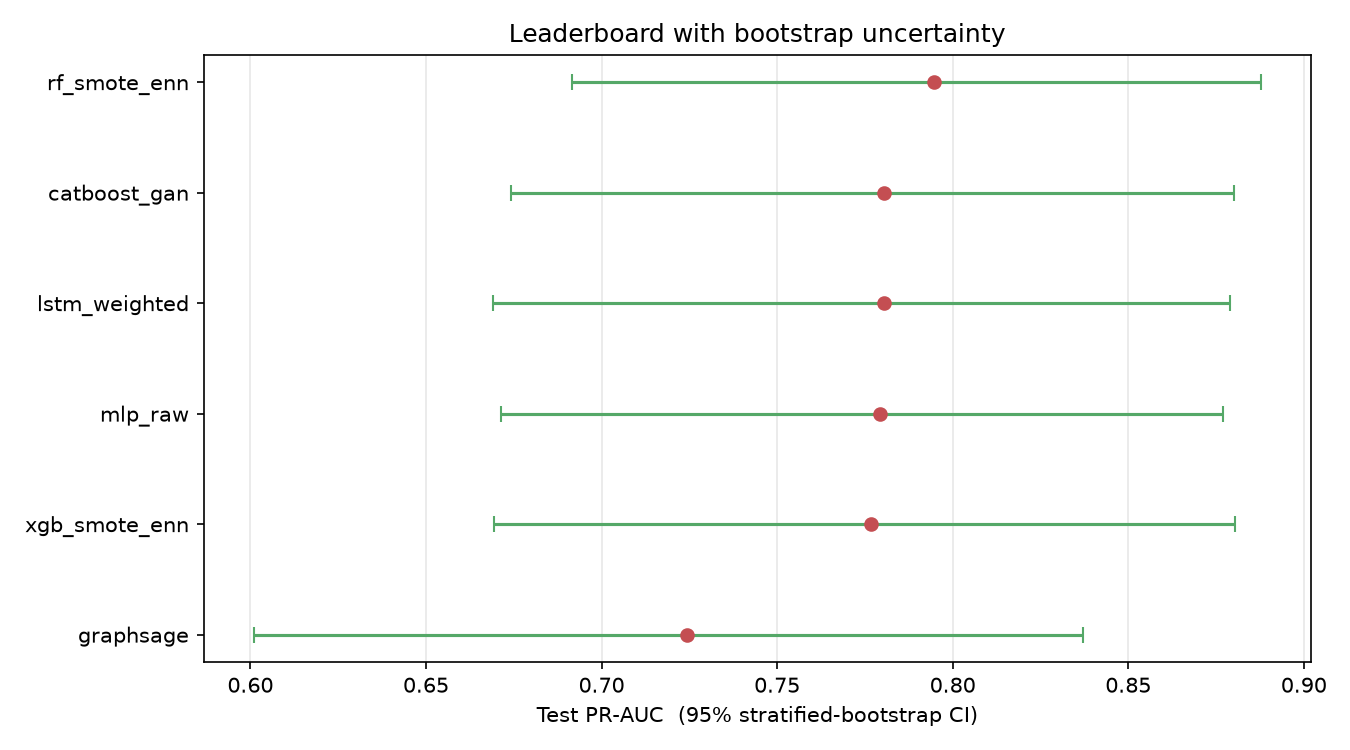

In [5]:
display(bootstrap[["config", "model", "strategy", "pr_auc",
                   "ci_low", "ci_high", "ci_width", "n_boot"]])
overlaps = 0
pairs = 0
for i in range(len(bootstrap)):
    for j in range(i + 1, len(bootstrap)):
        pairs += 1
        a, b = bootstrap.iloc[i], bootstrap.iloc[j]
        if not (a.ci_low > b.ci_high or b.ci_low > a.ci_high):
            overlaps += 1
print(f"\n{overlaps}/{pairs} pairwise comparisons are statistical ties")
band_lo = bootstrap["pr_auc"].min()
band_hi = bootstrap["ci_high"].max()
print("=> at 52 test frauds, NO model is separable from another;")
print(f"   the shared band ~{band_lo:.2f}-{band_hi:.2f} IS the result, not a ranking.")
display(Image(filename=str(FIG / "bootstrap_ci.png"), width=720))

## 5. Explainability — what drives the champion's decisions?

TreeExplainer SHAP on the champion RF+SMOTE-ENN (3,052 test rows:
52 frauds + 3,000 legit sample). Directions independently confirm Phase-1 EDA.

SHAP EXPLAINABILITY SUMMARY - RF + SMOTE-ENN CHAMPION
Explained rows      : 3052 (52 frauds, 3000 legit sample)
Base value (logit)  : 0.5010

Rank Feature     mean|SHAP|  Pushes toward
---------------------------------------------
1    V12         0.0906      LOW value  -> fraud
2    V14         0.0722      LOW value  -> fraud
3    V4          0.0710      HIGH value -> fraud
4    V10         0.0529      LOW value  -> fraud
5    V11         0.0456      HIGH value -> fraud
6    V17         0.0454      LOW value  -> fraud
7    V16         0.0210      LOW value  -> fraud
8    V3          0.0192      LOW value  -> fraud
9    V1          0.0158      LOW value  -> fraud
10   V7          0.0104      LOW value  -> fraud
11   log_Amount  0.0085      LOW value  -> fraud
12   Amount      0.0075      HIGH value -> fraud
13   V18         0.0063      LOW value  -> fraud
14   V2          0.0060      HIGH value -> fraud
15   V9          0.0054      LOW value  -> fraud

Figures: reports/figures/shap_*.p

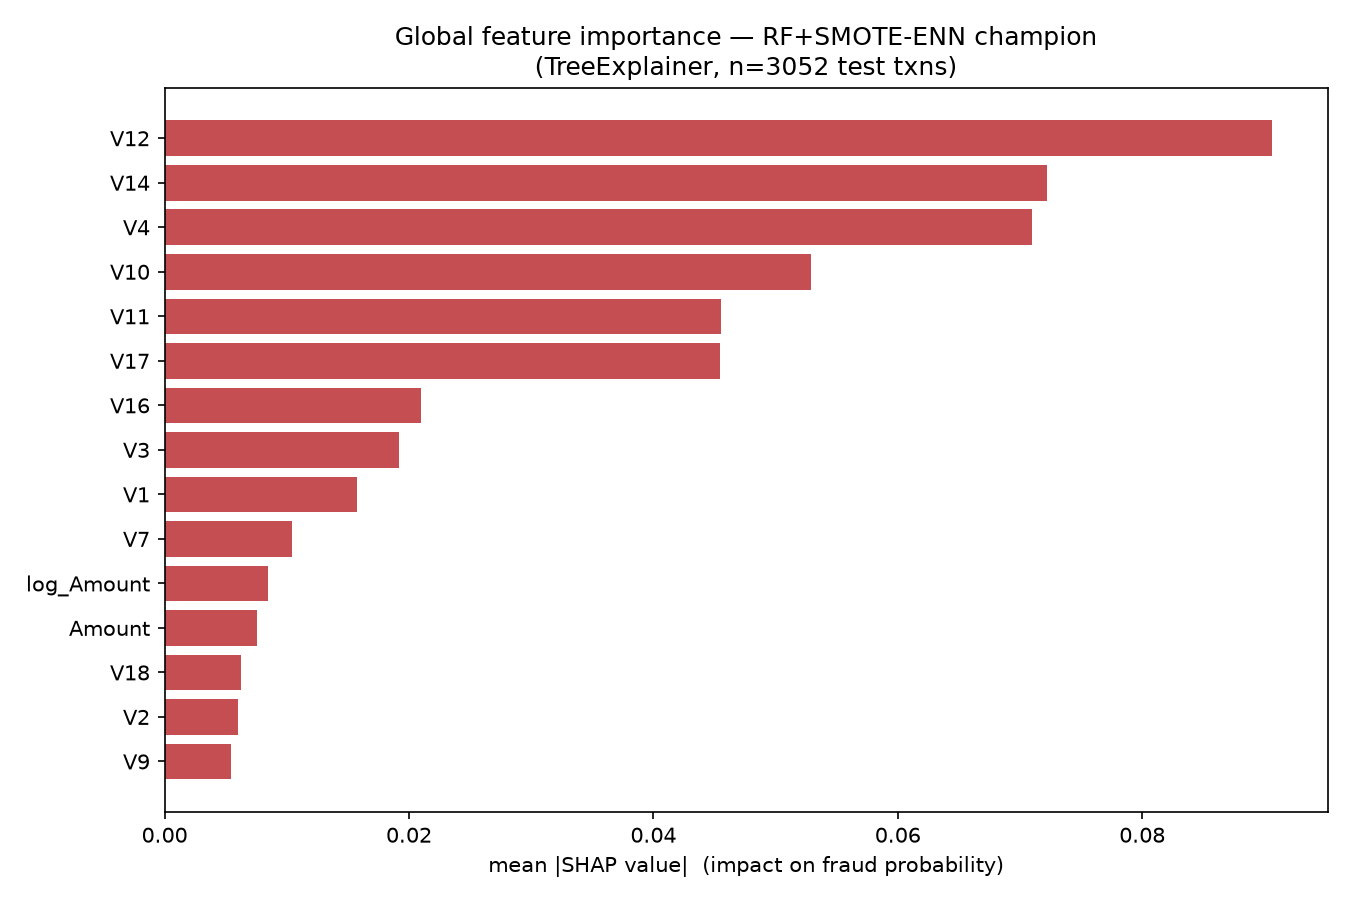

In [6]:
print((config.REPORTS / "shap_summary.txt").read_text(encoding="utf-8"))
display(Image(filename=str(FIG / "shap_global_importance.png"), width=680))

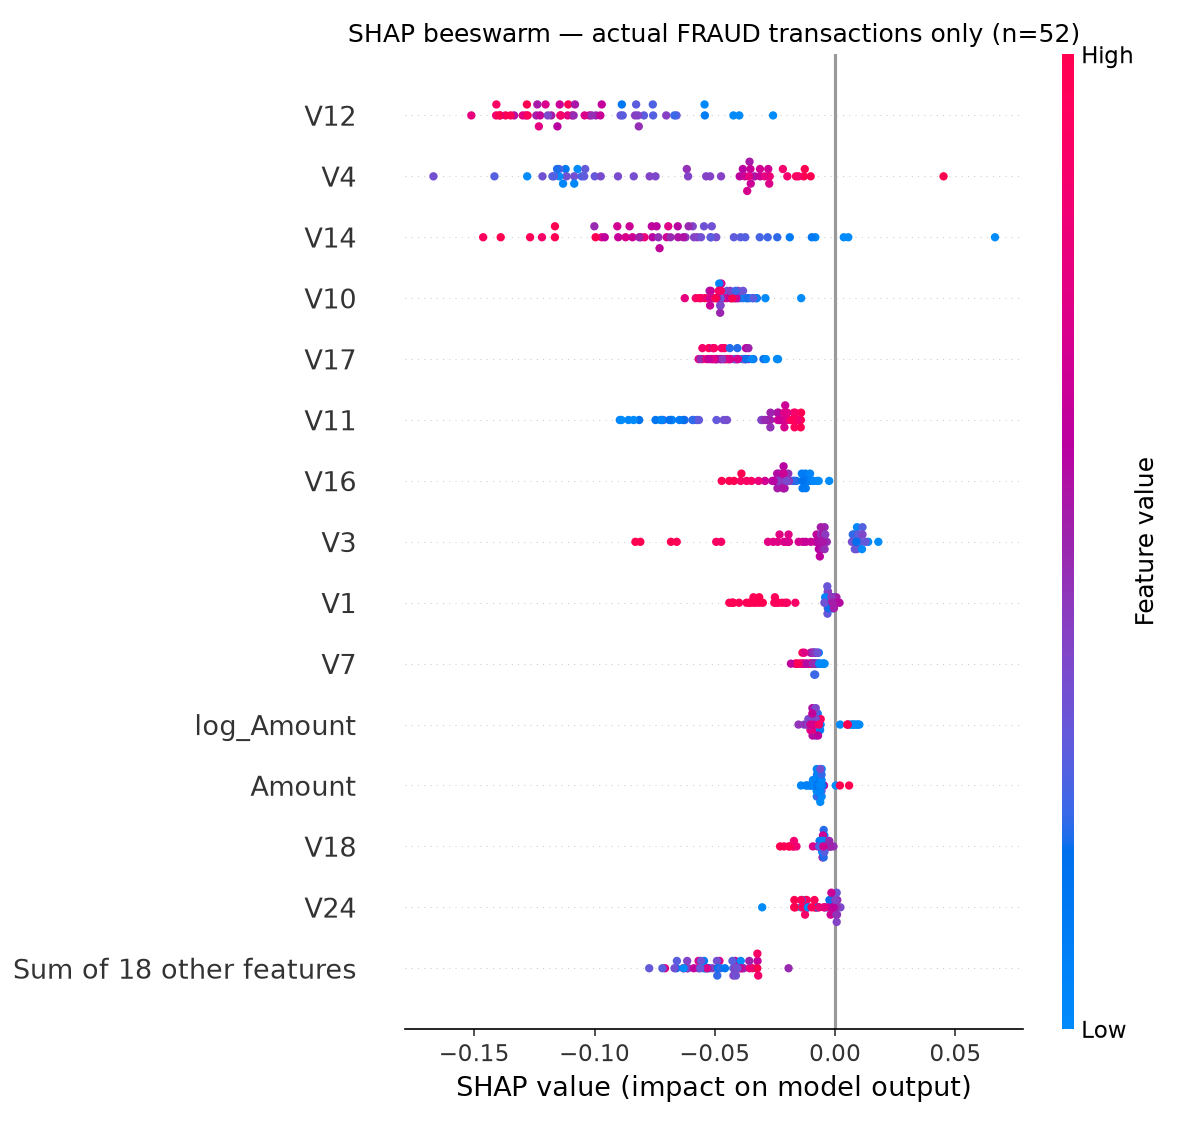

In [7]:
display(Image(filename=str(FIG / "shap_beeswarm_fraud.png"), width=720))

## 6. Standing against the literature (like-for-like)

| Protocol | Best known PR-AUC | Ours |
|---|---|---|
| Time-based split (honest) | ~0.75–0.80 range | **0.795 — top of range** |
| Random stratified (most papers) | ≈0.88 (EAI ISMLA 2026 XGBoost) | 0.840 (our own clean rerun, CatBoost+GAN) |
| Private bank data, random CV | 0.9879 (KAIS 2026 RF) | not comparable |

Measured ablation shows our shuffled-protocol scores land exactly where papers
report — the historical benchmark gap is **protocol, not model quality**.

## 7. Conclusions

1. **Champion:** Random Forest + SMOTE-ENN — PR-AUC 0.795, F1 0.848, MCC 0.855
   (97.5% precision @ 75% recall, one false positive in 42,722 transactions).
2. **No model is statistically separable** on this test window (all CIs overlap);
   the deliverable is the *protocol and the analysis*, not a leaderboard winner.
3. **Fraud drivers are stable and interpretable:** V12/V14/V10/V17 low → fraud,
   V11 high → fraud, small amounts → fraud (SHAP == EDA correlation signs).

**Limitations:** 52 test frauds (wide CIs); features are PCA-anonymized so no true
relational graph or business rules; single dataset (ULB, Sept-2013 Europe);
concept drift beyond two days untested.

**Future work:** entity-aware graphs (cardholder/merchant IDs), drift-aware online
learning, cost-sensitive thresholding with real fraud/interception costs,
calibration reporting (Brier/ECE).

---

### Appendix — reproducibility

| Artifact | Command |
|---|---|
| Data | `python -m src.data.make_dataset` |
| Classical tier | `python -m src.models.train_classical` |
| Deep tier | `python -m src.models.train_deep` |
| GNN tier | `python -m src.models.train_gnn` |
| Ensembles | `python -m src.models.train_ensembles` |
| Tuning | `python -m src.models.tune_optuna` |
| Split ablation | `python -m src.models.ablation_random_split` |
| Bootstrap CIs | `python -m src.models.bootstrap_ci` |
| SHAP | `python -m src.models.explain_shap` |
| Demo app | `.venv\Scripts\streamlit run app/streamlit_app.py` |

Environment: Python 3.12.14 venv, torch 2.13.0+cu130 (RTX 5050), seed 42 everywhere.